# MTL — Colab/Kaggle GPU training

Run cells top to bottom. This trains the shared ResNet50+FPN backbone
jointly on detection (RetinaNet) + semantic segmentation (FCN) +
multi-label classification, on a COCO subset.


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Projenizin Google Drive'da saklanacağı kök dizini tanımlayın.
# 'mtl_project' yerine Drive'ınızda istediğiniz herhangi bir klasör adını kullanabilirsiniz.
PROJECT_ROOT_DIR = '/content/drive/MyDrive/mtl_project'

# Proje dizinini yoksa oluşturun
os.makedirs(PROJECT_ROOT_DIR, exist_ok=True)

print(f"Proje dosyaları şu dizinde saklanacak: {PROJECT_ROOT_DIR}")
print("Bu hücreyi çalıştırdıktan sonra, '## 2. Get the repo' altındaki hücreyi çalıştırarak projenizi kurmaya devam edebilirsiniz.")

Mounted at /content/drive
Proje dosyaları şu dizinde saklanacak: /content/drive/MyDrive/mtl_project
Bu hücreyi çalıştırdıktan sonra, '## 2. Get the repo' altındaki hücreyi çalıştırarak projenizi kurmaya devam edebilirsiniz.


## 1. Install dependencies
Colab usually ships a CUDA-matched torch/torchvision already — only reinstall if missing.

In [2]:
import os

# PROJECT_ROOT_DIR değişkeni, 'Google Drive'ı bağlamak' hücresinde (ID: 18d6ac99) tanımlanmıştır.
# Bu hücre, depo işlemlerini gerçekleştirmek için doğru dizinde olduğumuzdan emin olur.
%cd {PROJECT_ROOT_DIR}

REPO_NAME = "mtl"
REPO_PATH = os.path.join(PROJECT_ROOT_DIR, REPO_NAME)

# Depo zaten klonlanmışsa, tekrar klonlamayı atlayın.
if not os.path.exists(REPO_PATH):
    print(f"{REPO_NAME} deposu {PROJECT_ROOT_DIR} dizinine klonlanıyor...")
    !git clone https://github.com/itu-itis23-ucgun22/mtl.git
    # Klonlamadan sonra depo dizinine geçin.
    %cd {REPO_PATH}
else:
    print(f"{REPO_NAME} deposu zaten {PROJECT_ROOT_DIR} dizininde mevcut. Klonlama atlanıyor.")
    # Zaten klonlanmışsa, sadece depo dizinine geçin.
    %cd {REPO_PATH}

print(f"Mevcut çalışma dizini: {os.getcwd()}")

/content/drive/MyDrive/mtl_project
mtl deposu /content/drive/MyDrive/mtl_project dizinine klonlanıyor...
Cloning into 'mtl'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 71 (delta 17), reused 66 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 36.66 KiB | 2.04 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/drive/MyDrive/mtl_project/mtl
Mevcut çalışma dizini: /content/drive/MyDrive/mtl_project/mtl


**Önemli:** Yukarıdaki hücrede (ID: `a38abd22`) GitHub deposu artık Google Drive'ınızdaki `PROJECT_ROOT_DIR` (`/content/drive/MyDrive/mtl_project` olarak varsayılmıştır) konumuna klonlanmaktadır. Bu sayede Colab oturumları arasında projeniz kalıcı olacaktır.

Depo klonlandıktan veya mevcut olduğu tespit edildikten sonra, çalışma dizini `{PROJECT_ROOT_DIR}/mtl` olarak ayarlanır. Artık bağımlılıkları yüklemek ve devam etmek için aşağıdaki hücreleri sırasıyla çalıştırmaya devam edebilirsiniz.

In [3]:
import torch
print(torch.__version__, torch.cuda.is_available())

# Uncomment only if the above shows no CUDA:
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

!pip install pycocotools PyYAML tqdm scikit-learn requests

2.11.0+cpu False


## 2. Get the repo
Either clone from git, or upload a zip of this project via the Colab file browser and unzip it.

In [4]:
# Depo bir önceki adımda (ID: a38abd22) klonlandığı ve çalışma dizini depo köküne ayarlandığı için,
# burada sadece paketi düzenlenebilir modda kurmamız yeterlidir.
!pip install -e .

Obtaining file:///content/drive/MyDrive/mtl_project/mtl
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mtl (pyproject.toml) ... done
  Created wheel for mtl: filename=mtl-0.1.0-0.editable-py3-none-any.whl size=1199 sha256=e4509721993665b1917be483298b1b770be59e4169ae9ad864df48ee68a2b6f1
  Stored in directory: /tmp/pip-ephem-wheel-cache-8xp7plfq/wheels/4a/45/5b/abd71b127cfd16d9e534ae2160c3137471dda092546fef32b0
Successfully built mtl


## 3. Build the COCO subset
Download full COCO annotations/images first (e.g. via the COCO website or Kaggle's COCO dataset), then filter down to the training subset.

In [5]:
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip

!python scripts/prepare_coco_subset.py \
    --ann-file annotations/instances_train2017.json \
    --out data/coco_subset/annotations/instances_train_subset.json \
    --n-images 22500
!python scripts/prepare_coco_subset.py \
    --ann-file annotations/instances_val2017.json \
    --out data/coco_subset/annotations/instances_val_subset.json \
    --n-images 2000

# Download only the subset's images (via each image's coco_url) - far
# cheaper than the full train2017.zip (~18GB) / val2017.zip (~1GB).
!python scripts/download_subset_images.py \
    --ann-file data/coco_subset/annotations/instances_train_subset.json \
    --out-dir data/coco_subset/images/train
!python scripts/download_subset_images.py \
    --ann-file data/coco_subset/annotations/instances_val_subset.json \
    --out-dir data/coco_subset/images/val

loading annotations into memory...
Done (t=23.04s)
creating index...
index created!
Wrote 22500 images to data/coco_subset/annotations/instances_train_subset.json
loading annotations into memory...
Done (t=1.03s)
creating index...
index created!
Wrote 2000 images to data/coco_subset/annotations/instances_val_subset.json
downloading images: 100% 22500/22500 [14:43<00:00, 25.46it/s]
Done. 22500/22500 images present in data/coco_subset/images/train.
downloading images: 100% 2000/2000 [01:19<00:00, 25.05it/s]
Done. 2000/2000 images present in data/coco_subset/images/val.


## 4. Train

In [10]:
!python scripts/train.py --config configs/train_colab_gpu.yaml --overrides train.max_steps=2813


loading annotations into memory...
Done (t=2.67s)
creating index...
index created!
Config: {'data': {'ann_file': 'data/coco_subset/annotations/instances_train_subset.json', 'img_dir': 'data/coco_subset/images/train', 'val_ann_file': 'data/coco_subset/annotations/instances_val_subset.json', 'val_img_dir': 'data/coco_subset/images/val', 'n_images': 22500, 'img_size': 512, 'num_workers': 2}, 'model': {'backbone_name': 'resnet50', 'pretrained': True, 'trainable_backbone_layers': 3, 'cls_head_tap': 'fpn_p5'}, 'loss': {'det_cls': 1.0, 'det_box': 1.0, 'seg': 1.0, 'cls': 0.5}, 'train': {'device': 'cuda', 'batch_size': 8, 'epochs': 16, 'max_steps': 2813, 'lr': 0.0001, 'weight_decay': 0.0001, 'amp': True, 'seed': 42, 'log_every': 20, 'checkpoint_dir': 'checkpoints', 'run_name': 'colab_gpu', 'checkpoint_every_steps': 500}}
[step 0] classification=1.1579 bbox_regression=0.7766 seg_loss=4.5766 cls_loss=0.6965 total=6.8593
[step 20] classification=1.0835 bbox_regression=0.7416 seg_loss=3.8929 cls_lo

## 5. Evaluate + visualize a few predictions

In [11]:
!python scripts/eval.py --config configs/train_colab_gpu.yaml --checkpoint checkpoints/colab_gpu_epoch0.pt

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.80s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=19.81s).
Accumulating evaluation results...
DONE (t=4.37s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.052
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.110
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.042
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.024
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.056
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.081
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.115
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.186
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:352: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")


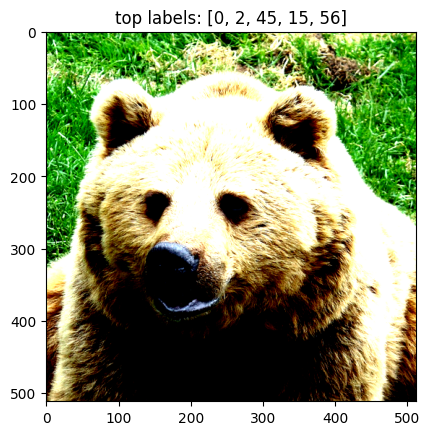

In [7]:
import sys
# PROJECT_ROOT_DIR değişkeni, 'Google Drive'ı bağlamak' hücresinde (ID: 18d6ac99) tanımlanmıştır.
# mtl paketinin Drive üzerindeki yoldan bulunabildiğinden emin olun.
sys.path.insert(0, f"{PROJECT_ROOT_DIR}/mtl/src")

import torch
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

# load_config için doğru içe aktarma yolunu düzeltme
from mtl.utils.config import load_config
from mtl.datasets.coco_multitask import CocoMultiTaskDataset
from mtl.engine.checkpoint import load_checkpoint
from mtl.models.multitask_model import MultiTaskModel
from mtl.utils.device import resolve_device

# Yapılandırma ve kontrol noktası yolları, mevcut çalışma dizinine (PROJECT_ROOT_DIR/mtl) göre göreceli olmalıdır.
cfg = load_config("configs/train_colab_gpu.yaml")
device = resolve_device(cfg.train.device)
dataset = CocoMultiTaskDataset(cfg.data.val_ann_file, cfg.data.val_img_dir, img_size=cfg.data.img_size, train=False)

model = MultiTaskModel(
    det_num_classes=dataset.num_classes,
    seg_num_classes=dataset.num_classes + 1,
    cls_num_labels=dataset.num_classes,
).to(device)
load_checkpoint(model, optimizer=None, path="checkpoints/colab_gpu_epoch0.pt", map_location=str(device))
model.eval()

image, target = dataset[0]
with torch.no_grad():
    out = model(image.unsqueeze(0).to(device))

det = out["detections"][0]
keep = det["scores"] > 0.5
img_uint8 = ((image * 0.5 + 0.5) * 255).clamp(0, 255).byte()
drawn = draw_bounding_boxes(img_uint8, det["boxes"][keep].cpu())
plt.imshow(drawn.permute(1, 2, 0))
plt.title(f"top labels: {out['cls_pred'][0].topk(5).indices.tolist()}")
plt.show()

In [8]:
import sys
sys.path.insert(0, "/content/mtl/src")

import torch
import matplotlib.pyplot as plt


In [9]:
# İlk olarak mtl dizinine geçin
%cd /content/mtl

# En son değişiklikleri çekin
!git pull

/content/mtl
Already up to date.
